In [1]:
# importando bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df_hoteldataset = pd.read_csv('/content/hotel_dataset_messy.csv')
df_hoteldataset.info()
display(df_hoteldataset.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Guest_Name          1500 non-null   object 
 1   Age                 1500 non-null   int64  
 2   Room_Type           1500 non-null   object 
 3   CheckIn_Date        1500 non-null   object 
 4   CheckOut_Date       1500 non-null   object 
 5   Booking_Channel     1500 non-null   object 
 6   Total_Charges       1500 non-null   float64
 7   Satisfaction_Score  1366 non-null   float64
dtypes: float64(2), int64(1), object(5)
memory usage: 93.9+ KB


,Guest_Name,Age,Room_Type,CheckIn_Date,CheckOut_Date,Booking_Channel,Total_Charges,Satisfaction_Score
0,pAulo chiavini,69,Standard,2025-08-21,2025-08-23,Site Oficial,296.967888,1.0
1,aNa pereira,32,Standard,2025-08-28,2025-09-10,Booking.com,2235.383385,5.0
2,luYz silva,78,Standard,2025-01-04,2025-01-18,Site Oficial,1907.702878,4.0
3,luYz silva,38,Deluxe,2025-06-30,2025-07-14,Booking.com,3751.333568,2.0
4,aNa silva,41,Deluxe,2025-02-28,2025-03-02,Booking.com,575.659560,3.0


# Tratando Outliars

In [3]:
# Calculando mediana das idades (somente as que fazem sentido)
mediana_idade = df_hoteldataset.loc[df_hoteldataset['Age'] < 100, 'Age'].median()

# Localiza e substitui valores "impossíveis"
df_hoteldataset.loc[df_hoteldataset['Age'] > 100, 'Age'] = mediana_idade

# Transforma valores negativos em nulos
df_hoteldataset.loc[df_hoteldataset['Total_Charges'] < 0, 'Total_Charges'] = np.nan

# Transformar Dados

 1. Traduzir índices
 2. Atribuir classificação para "Room_Type" e Satisfaction Type
 3. Arrumar nomes
 4. Arrumar datas para Datetime
 5. Incluir coluna de análise: tempo de estadia (check-out - check in)
 6. Arrumar "Total_Charges": casas decimais

In [4]:
# Tradução do Indexs utilizando dicionário
traducao_colunas = {
    'Room_Type': 'Tipo_Quarto',
    'Satisfaction_Score': 'Pontuacao_Satisfacao',
    'Total_Charges': 'Total_Gastos',
    'Guest_Name': 'Nome_Hospede',
    'CheckIn_Date' : 'Data_CheckIn',
    'CheckOut_Date' : 'Data_CheckOut',
    'Age' : 'Idade',
    'Booking_Channel' : 'Canal_de_Reserva'
}
# Aplicando tradução
df_hoteldataset = df_hoteldataset.rename(columns=traducao_colunas)

In [5]:
# Atribuindo classificação para "Pontuacao_Satisfacao"

limites = [0,2,4,5]
categorias = ['Baixa', 'Média','Alta']

# Criando nova coluna com classificação
df_hoteldataset['Classe_Satisfacao'] = pd.cut(df_hoteldataset['Pontuacao_Satisfacao'],bins=limites, labels=categorias)

In [6]:
# Atribuindo classificação para "Tipo_Quarto" transformando em Categoria Ordenada
from pandas.api.types import CategoricalDtype

# Definindo a ordem lógica dos quartos
ordem_quartos = CategoricalDtype(categories=['Standard', 'Delux', 'Suite'], ordered=True)

# Aplica a Transformação
df_hoteldataset['Tipo_Quarto'] = df_hoteldataset['Tipo_Quarto'].astype(ordem_quartos)

In [7]:
# Arrumando Nomes
df_hoteldataset['Nome_Hospede'] = df_hoteldataset['Nome_Hospede'].str.title()

In [8]:
# Removendo espaços em branco
df_hoteldataset['Tipo_Quarto'] = df_hoteldataset['Tipo_Quarto'].str.strip()

In [9]:
# Converte as colunas para Datetime
df_hoteldataset['Data_CheckIn'] = pd.to_datetime(df_hoteldataset['Data_CheckIn'])
df_hoteldataset['Data_CheckOut'] = pd.to_datetime(df_hoteldataset['Data_CheckOut'])

# Criando coluna para análise
df_hoteldataset['Tempo_Estadia'] = (df_hoteldataset['Data_CheckOut'] - df_hoteldataset['Data_CheckIn']).dt.days

In [10]:
# Arrumando casas decimais em "Total_Gastos"
df_hoteldataset['Total_Gastos'] = df_hoteldataset['Total_Gastos'].round(2)

In [11]:
# Removendo erros ocultos
df_hoteldataset = df_hoteldataset.drop_duplicates()

# Carregando Dados - Novo Arquivo

In [12]:
df_hoteldataset.to_csv('hotel_dataset_clean', index=False)

# Estatísticas

In [13]:
# Dados estatísticos do arquivo
display(df_hoteldataset.describe().round(2))

# Estatística por categoria
display(df_hoteldataset.describe(include=['O', 'object']))

,Idade,Data_CheckIn,Data_CheckOut,Total_Gastos,Pontuacao_Satisfacao,Tempo_Estadia
count,1500.00,1500,1500,1427.00,1366.00,1500.00
mean,50.60,2025-07-01 22:06:43.200000,2025-07-09 14:00:00.000000256,2126.28,3.63,7.66
min,2.00,2025-01-01 00:00:00,2025-01-04 00:00:00,135.31,1.00,1.00
25%,34.00,2025-03-29 00:00:00,2025-04-08 00:00:00,887.88,3.00,4.00
50%,50.00,2025-07-01 00:00:00,2025-07-10 00:00:00,1650.58,4.00,8.00
75%,68.00,2025-10-05 00:00:00,2025-10-13 00:00:00,2653.66,5.00,11.00
max,84.00,2026-01-01 00:00:00,2026-01-14 00:00:00,16379.30,5.00,14.00
std,19.74,NaN,NaN,2122.32,1.18,3.97


,Nome_Hospede,Tipo_Quarto,Canal_de_Reserva
count,1500,956,1500
unique,80,2,4
top,Julia Alves,Standard,Agencia
freq,31,748,387


# Gráficos

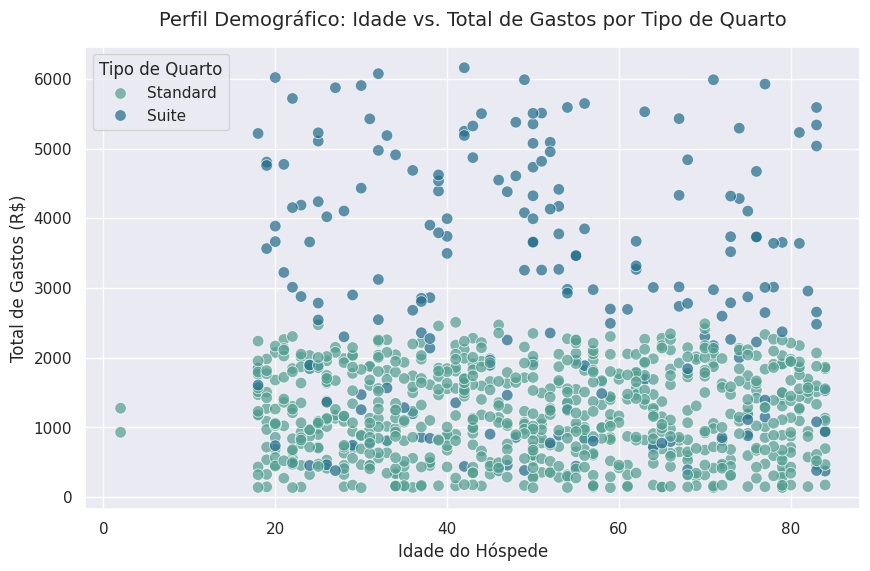

In [14]:
# Configurando estilos
sns.set_theme(style='darkgrid')
plt.figure(figsize=(10,6))

# Criando gráfico de Dispersão para Perfil Demográfico vs. Faturamento
sns.scatterplot(
    data = df_hoteldataset,
    x='Idade',
    y='Total_Gastos',
    hue ='Tipo_Quarto',
    palette='crest',
    alpha=0.7,
    s=70
)

# Alterando Tútulos e Eixos
plt.title('Perfil Demográfico: Idade vs. Total de Gastos por Tipo de Quarto', fontsize=14, pad=15)
plt.xlabel('Idade do Hóspede', fontsize=12)
plt.ylabel('Total de Gastos (R$)', fontsize=12)
plt.legend(title='Tipo de Quarto')

plt.show()

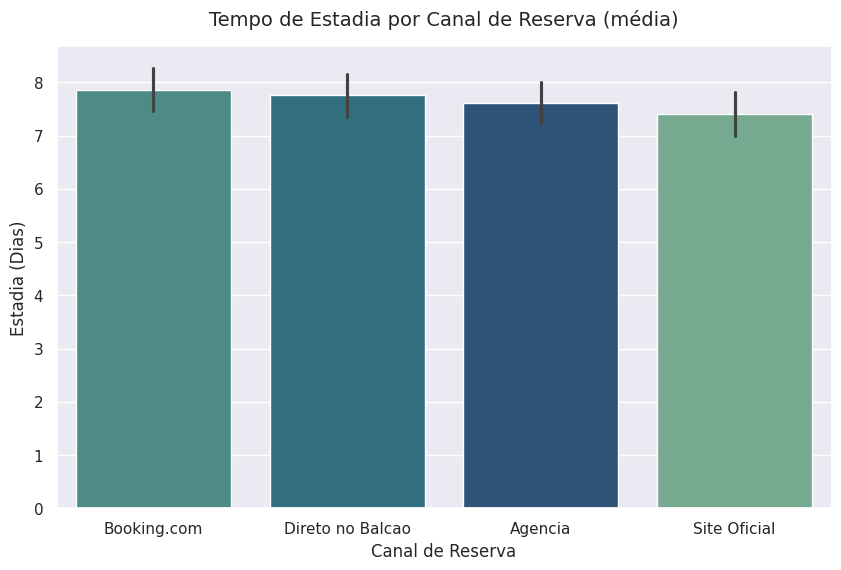

In [19]:
plt.figure(figsize=(10, 6))

# Agrupa os dados para ordenar as barras da maior para a menor média
ordem_canais = df_hoteldataset.groupby('Canal_de_Reserva')['Tempo_Estadia'].mean().sort_values(ascending=False).index

# Cria o gráfico de barras (calcula automaticamente a média e o intervalo de confiança)
sns.barplot(
    data=df_hoteldataset,
    x='Canal_de_Reserva',
    y='Tempo_Estadia',
    order=ordem_canais,
    palette='crest',
    hue='Canal_de_Reserva', # Necessário em versões recentes do Seaborn para aplicar a paleta
    legend=False
)

# Customização
plt.title('Tempo de Estadia por Canal de Reserva (média)', fontsize=14, pad=15)
plt.xlabel('Canal de Reserva', fontsize=12)
plt.ylabel('Estadia (Dias)', fontsize=12)

plt.show()

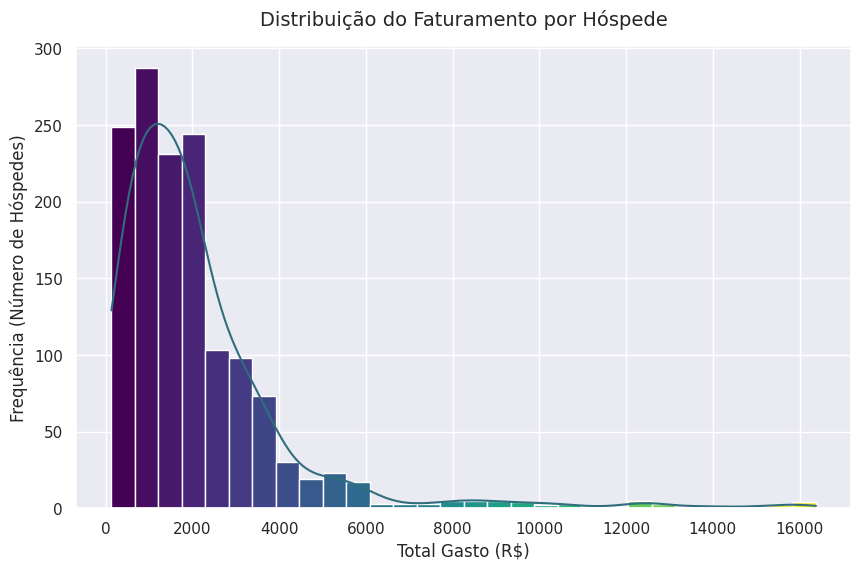

In [21]:
plt.figure(figsize=(10, 6))

# Cria o histograma com a linha de densidade (KDE)
sns.histplot(
    data=df_hoteldataset,
    x='Total_Gastos',
    kde=True,            # Adiciona a linha de tendência/densidade
    bins=30,             # Quantidade de fatias do gráfico
    color='#306d7d'
)


from matplotlib.colors import Normalize
from matplotlib.cm import viridis

# Pega as barras geradas pelo matplotlib
plt.gca()
patches = plt.gca().patches
if patches:
    # Normaliza os valores do eixo X para mapear na paleta
    fracs = [p.get_x() for p in patches]
    norm = Normalize(min(fracs), max(fracs))

    # Aplica a cor crest correspondente a cada barra
    for thisfrac, thispatch in zip(fracs, patches):
        color = viridis(norm(thisfrac))
        thispatch.set_facecolor(color)

# Customização
plt.title('Distribuição do Faturamento por Hóspede', fontsize=14, pad=15)
plt.xlabel('Total Gasto (R$)', fontsize=12)
plt.ylabel('Frequência (Número de Hóspedes)', fontsize=12)

plt.show()